## Step 1: Import Required Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split

from transformers import AutoTokenizer

plt.style.use("ggplot")

### Observation

- All required libraries were imported successfully.
- **Pandas** and **NumPy** will be used for data manipulation.
- **Matplotlib** and **Seaborn** will be used for data visualization.
- **WordCloud** will help visualize frequently occurring words.
- **AutoTokenizer** from Hugging Face will be used later to tokenize tweet text for transformer-based models.

## Step 2: Load the Dataset

In [7]:
# Load the dataset

import pandas as pd

df = pd.read_csv("../data/twitter_disaster.csv")

print("✅ Dataset Loaded Successfully")
print(f"Dataset Shape: {df.shape}")

df.head()

✅ Dataset Loaded Successfully
Dataset Shape: (7613, 5)


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


### Observation

• The disaster tweet dataset was loaded successfully.

• The dataset contains tweets along with their corresponding disaster labels.

• The first five records provide an overview of the dataset structure.

• This dataset will be used for preprocessing, EDA, sentiment analysis, and model training.


## Step 3: Check Dataset Shape

In [8]:
print("Dataset Shape:", df.shape)

Dataset Shape: (7613, 5)


### Observation

- The dataset shape indicates the total number of observations (rows) and features (columns).
- This helps understand the overall size of the dataset before preprocessing.

## Step 4: View Dataset

In [9]:
df.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


### Observation

- The dataset contains columns such as **id**, **keyword**, **location**, **text**, and **target**.
- The **text** column contains the tweet content, while the **target** column indicates whether the tweet is related to a disaster or not.

## Step 5: Check Missing Values

In [10]:
# Check missing values

missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

Missing Values:
id             0
keyword       61
location    2533
text           0
target         0
dtype: int64


### Observation
• The dataset contains missing values in the keyword and location columns.

• The text and target columns do not contain missing values.

• Since keyword and location are not essential for tweet classification, they can either be ignored or filled later if required.


## Step 6: Check Duplicate Records

In [11]:
# Check duplicate records

duplicates = df.duplicated().sum()

print("Duplicate Records:", duplicates)

Duplicate Records: 0


### Observation

- The dataset was checked for duplicate records.
- Duplicate tweets can negatively affect the model by introducing repeated information.
- Any duplicate records found will be removed before further preprocessing.

## Step 7: Remove Duplicate Records

In [12]:
# Remove duplicate records

initial_shape = df.shape

df.drop_duplicates(inplace=True)

print("Initial Shape:", initial_shape)
print("New Shape:", df.shape)
print("Duplicate records removed successfully.")

Initial Shape: (7613, 5)
New Shape: (7613, 5)
Duplicate records removed successfully.


### Observation

- Duplicate records were removed successfully from the dataset.
- Removing duplicate tweets improves data quality and reduces redundancy.
- The cleaned dataset will be used for the remaining preprocessing and model training steps.

## Step 8: Analyze Class Distribution

target
0    4342
1    3271
Name: count, dtype: int64


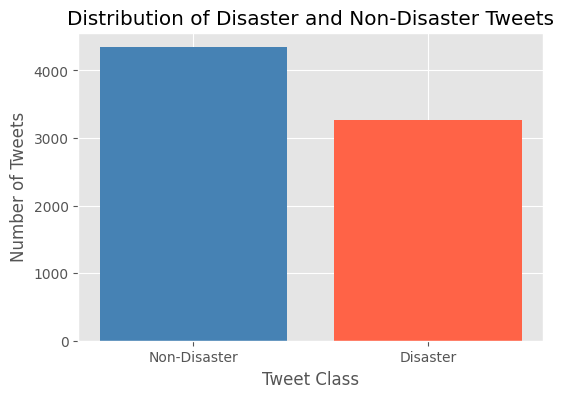

In [13]:
import matplotlib.pyplot as plt

# Count Disaster and Non-Disaster tweets
class_counts = df["target"].value_counts().sort_index()

print(class_counts)

plt.figure(figsize=(6,4))
plt.bar(["Non-Disaster", "Disaster"], class_counts.values, color=["steelblue", "tomato"])

plt.title("Distribution of Disaster and Non-Disaster Tweets")
plt.xlabel("Tweet Class")
plt.ylabel("Number of Tweets")

plt.show()

### Observation

- The distribution of Disaster and Non-Disaster tweets was analyzed.
- The dataset appears reasonably balanced between both classes.
- Understanding class distribution helps evaluate whether the model may be biased toward a particular class.

## Step 9: Analyze Tweet Length

In [14]:
# Calculate tweet length

df["tweet_length"] = df["text"].apply(len)

print(df["tweet_length"].describe())

count    7613.000000
mean      101.037436
std        33.781325
min         7.000000
25%        78.000000
50%       107.000000
75%       133.000000
max       157.000000
Name: tweet_length, dtype: float64


### Observation

- Tweet length statistics were calculated for all tweets.
- Most tweets have a moderate number of characters, which is expected for Twitter data.
- This information helps understand the characteristics of the dataset before text preprocessing.

## Step 10: Visualize Tweet Length Distribution

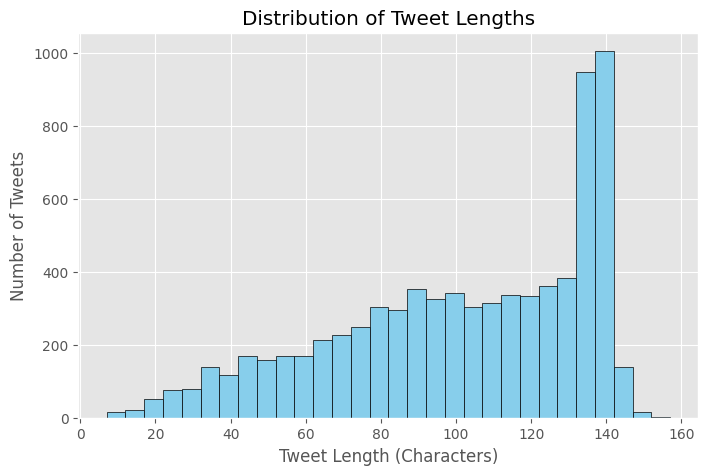

In [15]:
# Visualize tweet length distribution

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["tweet_length"], bins=30, color="skyblue", edgecolor="black")

plt.title("Distribution of Tweet Lengths")
plt.xlabel("Tweet Length (Characters)")
plt.ylabel("Number of Tweets")

plt.show()

### Observation

- The histogram shows the distribution of tweet lengths in the dataset.
- Most tweets have a moderate number of characters.
- Very short and very long tweets are comparatively less frequent.

## Step 11: Generate Word Cloud for Disaster Tweets

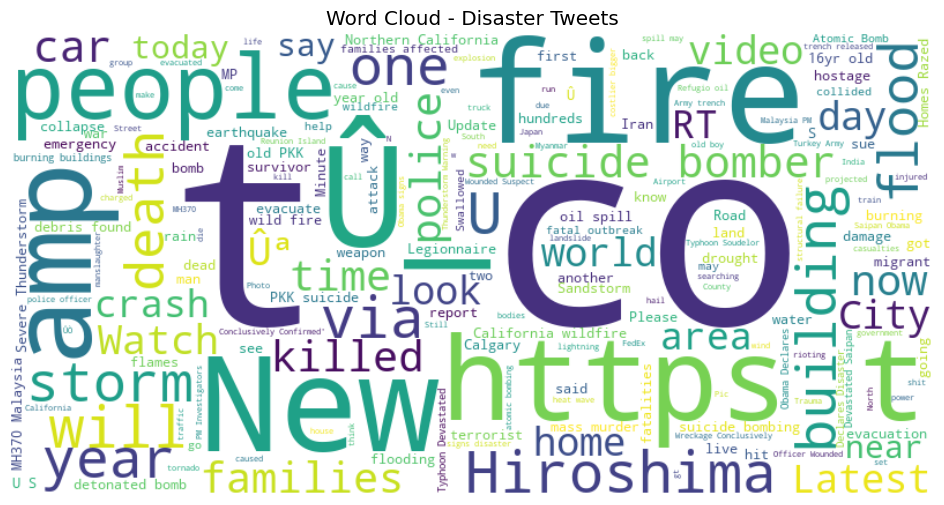

In [16]:
from wordcloud import WordCloud

# Combine all disaster tweets

disaster_text = " ".join(df[df["target"] == 1]["text"].astype(str))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(disaster_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - Disaster Tweets")

plt.show()

### Observation

- The word cloud highlights the most frequently occurring words in Disaster tweets.
- Larger words indicate higher frequency within the disaster-related tweets.
- This visualization helps identify common disaster-related terms in the dataset.

## Step 12: Generate Word Cloud for Non-Disaster Tweets

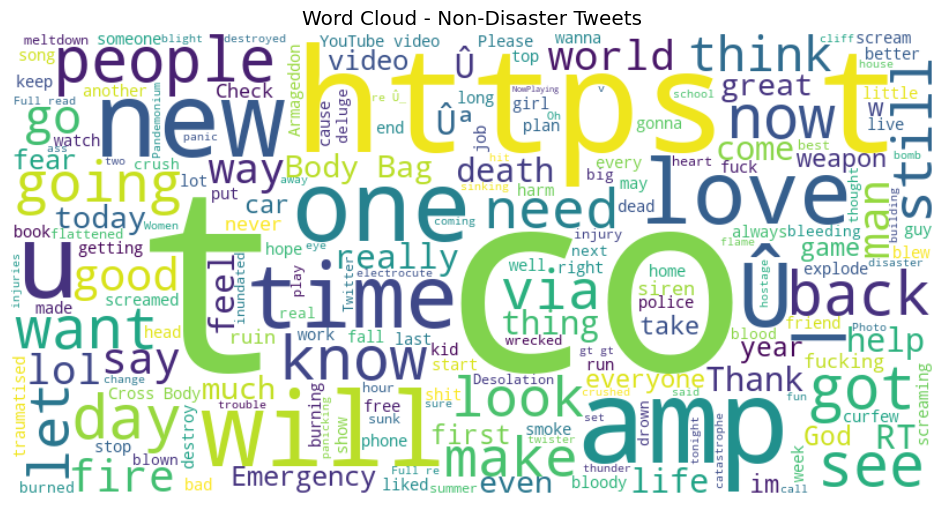

In [17]:
# Combine all non-disaster tweets

non_disaster_text = " ".join(df[df["target"] == 0]["text"].astype(str))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(non_disaster_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - Non-Disaster Tweets")

plt.show()

### Observation

- The word cloud displays the most common words found in Non-Disaster tweets.
- Frequently appearing words are represented with larger font sizes.
- Comparing both word clouds helps understand differences between the two tweet categories.

## Step 13: Install Hugging Face Transformers

In [18]:
!pip install transformers torch -q


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\hp\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


### Observation

- The required Hugging Face libraries were installed successfully.
- These libraries provide pre-trained transformer models for NLP tasks.
- They will be used to perform sentiment analysis on tweets.

## Step 14: Import Hugging Face Libraries

In [19]:
from transformers import pipeline

print("✅ Hugging Face pipeline imported successfully!")

✅ Hugging Face pipeline imported successfully!


### Observation

- The Hugging Face `pipeline` module was imported successfully.
- The `pipeline` function provides a simple interface for using pre-trained transformer models.
- It will be used to perform sentiment analysis on tweets in the following steps.

## Step 15: Load Pre-trained Sentiment Analysis Model

In [20]:
# Load the pre-trained DistilBERT sentiment analysis model

sentiment_pipeline = pipeline(
    task="sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

print("✅ Hugging Face Sentiment Model Loaded Successfully!")

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 3031.41it/s]


✅ Hugging Face Sentiment Model Loaded Successfully!


### Observation

- The pre-trained DistilBERT sentiment analysis model was loaded successfully.
- The model is fine-tuned on the SST-2 dataset for binary sentiment classification.
- It can predict whether a tweet has **Positive** or **Negative** sentiment with a confidence score.

## Step 16: Test the Sentiment Analysis Model

In [21]:
# Test the Hugging Face sentiment model

sample_tweet = "A massive fire broke out in the city."

result = sentiment_pipeline(sample_tweet)

print(result)

[{'label': 'NEGATIVE', 'score': 0.5392761826515198}]


### Observation

- The pre-trained sentiment analysis model successfully predicted the sentiment of the sample tweet.
- The output contains both the predicted sentiment label and its confidence score.
- This confirms that the Hugging Face sentiment model is working correctly and is ready to analyze the dataset.

## Step 17: Perform Sentiment Analysis on All Tweets

In [22]:
# Perform sentiment analysis on all tweets

df["sentiment"] = df["text"].apply(
    lambda tweet: sentiment_pipeline(tweet)[0]["label"]
)

print("✅ Sentiment analysis completed successfully!")

df[["text", "sentiment"]].head()

✅ Sentiment analysis completed successfully!


,text,sentiment
0,Our Deeds are the Reason of this #earthquake M...,NEGATIVE
1,Forest fire near La Ronge Sask. Canada,NEGATIVE
2,All residents asked to 'shelter in place' are ...,NEGATIVE
3,"13,000 people receive #wildfires evacuation or...",NEGATIVE
4,Just got sent this photo from Ruby #Alaska as ...,NEGATIVE


### Observation

- Sentiment analysis was performed on every tweet in the dataset.
- A new **sentiment** column was created containing either **POSITIVE** or **NEGATIVE** for each tweet.
- This additional feature enriches the dataset and can be used for further analysis or model improvement.

## Step 18: Analyze Sentiment Distribution

In [23]:
# Count Positive and Negative sentiments

sentiment_counts = df["sentiment"].value_counts()

print("Sentiment Distribution:")
print(sentiment_counts)

Sentiment Distribution:
sentiment
NEGATIVE    6396
POSITIVE    1217
Name: count, dtype: int64


### Observation

- The sentiment distribution shows the number of Positive and Negative tweets.
- This helps understand the overall emotional tone of the dataset.
- The sentiment feature can be compared with disaster labels for further analysis.

## Step 19: Visualize Sentiment Distribution

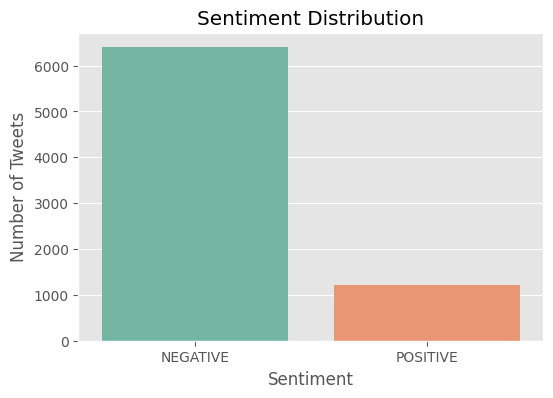

In [24]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="sentiment",
    data=df,
    palette="Set2"
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")

plt.show()

### Observation

- The bar chart clearly shows the distribution of Positive and Negative tweets.
- It provides a quick visual understanding of the sentiment balance in the dataset.
- This visualization helps identify whether one sentiment category dominates the dataset.

## Step 20: Save the Processed Dataset

In [25]:
df.to_csv("../data/processed_twitter_disaster.csv", index=False)

print("✅ Processed dataset saved successfully.")

✅ Processed dataset saved successfully.


### Observation

- The dataset was successfully saved after preprocessing.
- The saved file includes the cleaned data along with the newly generated sentiment column.
- This processed dataset will be used in the next notebook for model training.